# 11 — Style Interaction Matrix

**Goal:** Core matchup-asymmetry analysis. Uses GMM cluster assignments (k=5) to answer:
1. **Who beats whom?** — Win-rate matrix by style pair (Style A rows vs Style B columns)
2. **Are hybrids better?** — Win rate vs. Hybrid Score (entropy of cluster probabilities)
3. **Do styles make fights?** — Chi-square test for style–outcome significance

**Input:** `ufc_fight_stats_cleaned.csv`, `ufc_gmm_comparison.csv`

**Takeaway:** Values > 0.5 mean Style A wins more often; < 0.5 means Style B dominates. Strong asymmetries suggest style matchups matter. Chi-square p < 0.05 implies style is not random with respect to outcome.

In [19]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 11_style_interaction_matrix.ipynb | code cell index: 1
# Section (from markdown above): 11 — Style Interaction Matrix
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.

# --- Core pipeline load for this notebook ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# Load Datasets
# 1. The Fights (Outcomes)
fights = pd.read_csv('../data/processed/ufc_fight_stats_cleaned.csv')
# 2. The Styles (Clusters from GMM - k=5)
styles = pd.read_csv('../data/processed/ufc_gmm_comparison.csv')

# Check which cluster column to use (k=5 is recommended)
cluster_col = 'Cluster_k5' 
entropy_col = 'Hybrid_Score_k5'

print(f"Loaded {len(fights)} fights and {len(styles)} fighters.")

Loaded 16964 fights and 1190 fighters.


## 1. Create the Matchup Dataset
We merge the style info for both Fighter A and Fighter B into the fight dataframe.

In [20]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 11_style_interaction_matrix.ipynb | code cell index: 3
# Section (from markdown above): 1. Create the Matchup Dataset
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# Joins tables on fighter, fight, or event keys.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Merges link fighters, fights, styles, or odds on shared keys.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# 1. Load Datasets
fights = pd.read_csv('../data/processed/ufc_fight_stats_cleaned.csv')
styles = pd.read_csv('../data/processed/ufc_gmm_comparison.csv')

# Define the columns based on the k=5 model
cluster_col = 'Cluster_k5' 
entropy_col = 'Hybrid_Score_k5'

print(f"Loaded {len(fights)} fights and {len(styles)} fighters.")

# 2. Prepare Styles Table
style_map = styles[['Fighter', cluster_col, entropy_col]].set_index('Fighter')

# Merge Fighter A Style
df = fights.merge(style_map, left_on='Fighter', right_index=True, how='inner')
df = df.rename(columns={cluster_col: 'Style_A', entropy_col: 'Entropy_A'})

# Merge Fighter B Style
df = df.merge(style_map, left_on='Opponent', right_index=True, how='inner')
df = df.rename(columns={cluster_col: 'Style_B', entropy_col: 'Entropy_B'})

# Outcome
df['Win_A'] = df['Won'].astype(int)

print(f"Matchup Dataset Ready: {len(df)} fights with style data.")

Loaded 16964 fights and 1190 fighters.
Matchup Dataset Ready: 11084 fights with style data.


## 2. The Interaction Matrix (Heatmap)
We calculate the Win Rate of **Style A** (Rows) vs. **Style B** (Columns).
* **Value > 0.50:** Style A has the advantage.
* **Value < 0.50:** Style B has the advantage.

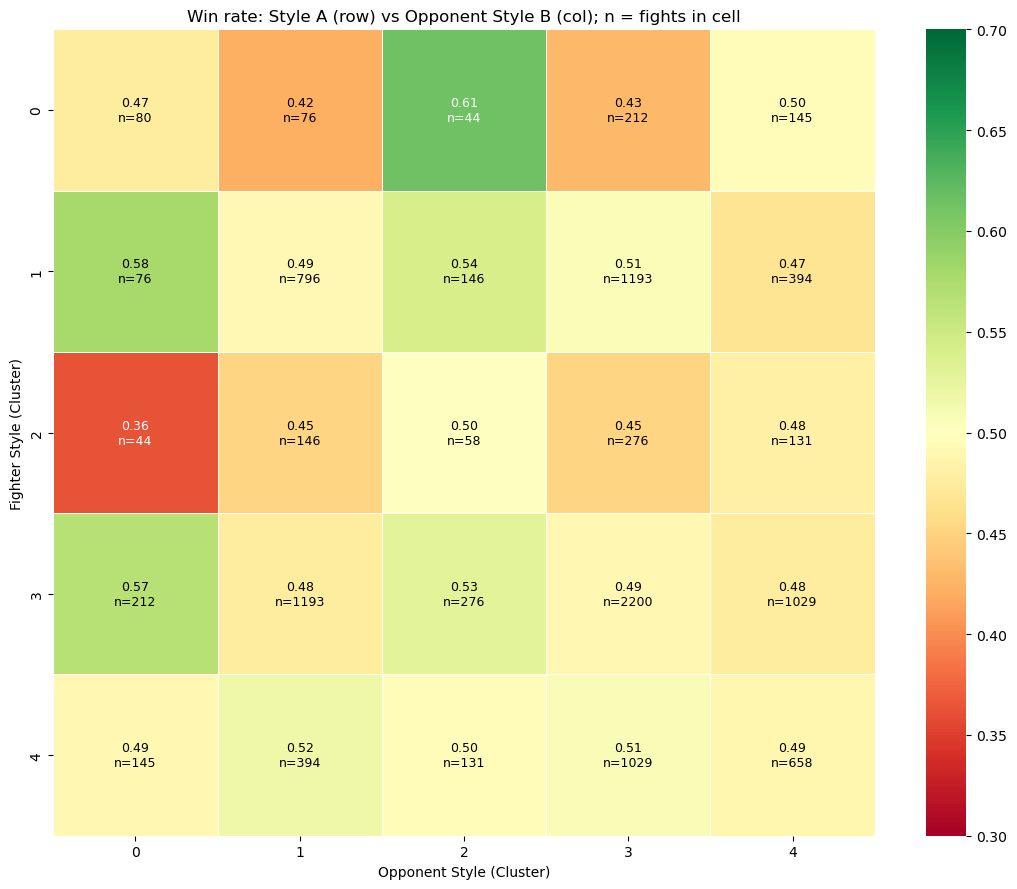

In [21]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 11_style_interaction_matrix.ipynb | code cell index: 5
# Section (from markdown above): 2. The Interaction Matrix (Heatmap)
# ------------------------------------------------------------------------
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Pivot tables build matrices (e.g., style vs style win rates).

# Pivot: win rate and number of directional fights per (row cluster, col cluster)
win_matrix = df.pivot_table(index='Style_A', columns='Style_B', values='Win_A', aggfunc='mean')
count_matrix = df.pivot_table(index='Style_A', columns='Style_B', values='Win_A', aggfunc='count')

# Draw labels with ax.text — seaborn's annot= can omit multi-line strings on some rows (matplotlib clipping).
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    win_matrix,
    ax=ax,
    annot=False,
    cmap='RdYlGn',
    center=0.5,
    vmin=0.3,
    vmax=0.7,
    linewidths=0.5,
    linecolor='white',
)
for i, r in enumerate(win_matrix.index):
    for j, c in enumerate(win_matrix.columns):
        w, n = win_matrix.loc[r, c], count_matrix.loc[r, c]
        if pd.isna(w):
            continue
        txt = f'{w:.2f}\nn={int(n)}'
        # Contrast: dark text on pale cells, light text on saturated red/green
        lum = (w - 0.3) / 0.4  # 0..1 over colormap span
        color = 'white' if (lum < 0.25 or lum > 0.75) else 'black'
        ax.text(j + 0.5, i + 0.5, txt, ha='center', va='center', fontsize=9, color=color)
ax.set_title('Win rate: Style A (row) vs Opponent Style B (col); n = fights in cell')
ax.set_xlabel('Opponent Style (Cluster)')
ax.set_ylabel('Fighter Style (Cluster)')
plt.tight_layout()
plt.show()

**Interpretation of win-probability heatmap:** Each cell = win rate of Style A (row) vs Style B (column). The second line is **n**, the number of **directional** fights in that cell (one row per fighter-in-`Fighter` perspective, so the same bout appears once as (A,B) and once as (B,A)). Values > 0.5 = Style A wins more often in that pairing; < 0.5 = Style B wins more often. Diagonal cells (same cluster vs same cluster) should be near 0.5. Off-diagonal asymmetry suggests exploitable matchup dynamics—check **n** before over-interpreting thin cells.

### 2b. High-profile fights vs the heatmap

Each bout is read from the **row fighter’s** viewpoint (same as the matrix). **Cluster labels** below are shorthand from notebook 10 (centroid + example names—not official “types,” just intuition).

| Cluster | Sketch (k=5) |
|--------|----------------|
| 0 | Submission / grappling-forward (e.g. Oliveira, Maia in examples) |
| 1 | Distance striking, lighter grappling pace (e.g. Holloway, Barboza) |
| 2 | Mixed / moderate profile |
| 3 | Volume / durable all-around (e.g. Cerrone, RDA, Guida in examples) |
| 4 | Wrestle-heavy, control time (e.g. Khabib, GSP, Lesnar) |

We compare **P(row fighter wins | row cluster vs col cluster)** from the heatmap to a **single** famous outcome. One fight is a noisy draw from that cell—use the heatmap as a **population** benchmark, not a prophecy.

In [22]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 11_style_interaction_matrix.ipynb | code cell index: 8
# Section (from markdown above): 2b. High-profile fights vs the heatmap
# ------------------------------------------------------------------------
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

CLUSTER_SKETCH_K5 = {
    0: "grappling/submission-forward",
    1: "distance striker",
    2: "mixed",
    3: "volume / all-around",
    4: "wrestle-dominant / control",
}


def spotcheck_fight(fighter_a, opponent_b, headline=""):
    """Row = fighter_a's perspective (matches matrix rows)."""
    row = df[(df["Fighter"] == fighter_a) & (df["Opponent"] == opponent_b)]
    if row.empty:
        print(f"— No merged row: {fighter_a} vs {opponent_b}\n")
        return
    sa, sb = int(row["Style_A"].iloc[0]), int(row["Style_B"].iloc[0])
    won = bool(row["Win_A"].iloc[0])
    p = win_matrix.loc[sa, sb]
    n = int(count_matrix.loc[sa, sb])
    aligned = (won and p > 0.5) or ((not won) and p < 0.5)
    print(headline or f"{fighter_a} vs {opponent_b}")
    print(f"  Styles: {fighter_a} → cluster {sa} ({CLUSTER_SKETCH_K5[sa]}); "
          f"{opponent_b} → cluster {sb} ({CLUSTER_SKETCH_K5[sb]})")
    print(f"  Heatmap cell ({sa},{sb}): P(A wins) ≈ {p:.3f} over n={n} fights")
    print(f"  Result: {'A won' if won else 'B won'} → "
          f"{'consistent with' if aligned else 'opposite of'} cell vs 0.5 (one noisy draw)\n")


spotcheck_fight(
    "Khabib Nurmagomedov",
    "Conor McGregor",
    "UFC 229 — wrestle-heavy (4) vs striker (1)",
)
spotcheck_fight(
    "Georges St-Pierre",
    "Josh Koscheck",
    "Welterweight rival — control style (4) vs gritty wrestler in cluster 0",
)
spotcheck_fight(
    "Israel Adesanya",
    "Marvin Vettori",
    "Middleweight — striker-like (1) vs cluster-3 pressure (first meeting in data)",
)

UFC 229 — wrestle-heavy (4) vs striker (1)
  Styles: Khabib Nurmagomedov → cluster 4 (wrestle-dominant / control); Conor McGregor → cluster 1 (distance striker)
  Heatmap cell (4,1): P(A wins) ≈ 0.518 over n=394 fights
  Result: A won → consistent with cell vs 0.5 (one noisy draw)

Welterweight rival — control style (4) vs gritty wrestler in cluster 0
  Styles: Georges St-Pierre → cluster 4 (wrestle-dominant / control); Josh Koscheck → cluster 0 (grappling/submission-forward)
  Heatmap cell (4,0): P(A wins) ≈ 0.490 over n=145 fights
  Result: A won → opposite of cell vs 0.5 (one noisy draw)

Middleweight — striker-like (1) vs cluster-3 pressure (first meeting in data)
  Styles: Israel Adesanya → cluster 1 (distance striker); Marvin Vettori → cluster 3 (volume / all-around)
  Heatmap cell (1,3): P(A wins) ≈ 0.505 over n=1193 fights
  Result: A won → consistent with cell vs 0.5 (one noisy draw)



**Reading the three checks:** Khabib–McGregor sits in a well-filled cell (4 vs 1); Khabib’s win matches a modest edge for cluster 4 in that pairing. Adesanya–Vettori (1 vs 3) is also in a **large-n** cell (~1193); Izzy’s win matches a heatmap slightly above 0.5—again, population vs one fight. GSP–Koscheck is **near 0.5** in cell (4 vs 0) (~0.49 with n=145), so the matrix is effectively a toss-up; both of GSP’s decision wins in the dataset are still plausible even though the aggregate tilts slightly toward cluster 0 from that row’s perspective.

## 3. Hypothesis Test: Are Hybrids Better?
We plot Win Rate vs. Entropy. 
* **Theory:** High Entropy (Hybrid) fighters are harder to gameplan against -> Higher Win Rate.

/var/folders/sk/j1374_rn5qx4kt2s8nz2ykk40000gn/T/ipykernel_83777/1481691818.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_by_entropy = df.groupby('Entropy_Bin')['Win_A'].mean()


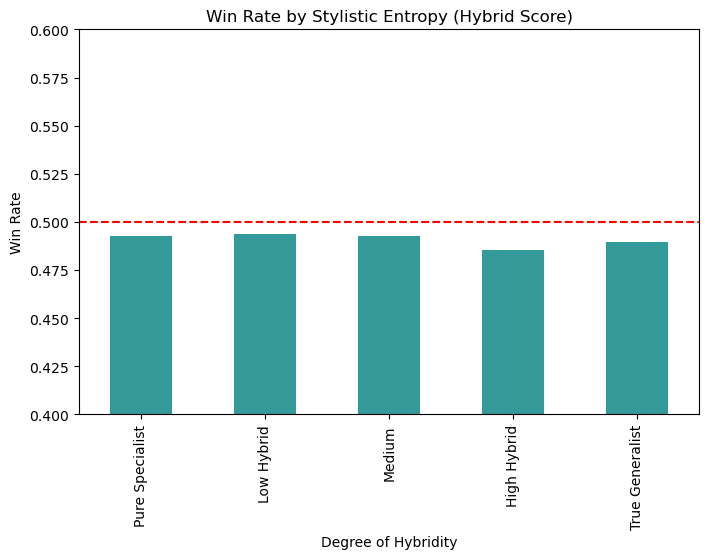

In [23]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 11_style_interaction_matrix.ipynb | code cell index: 11
# Section (from markdown above): 3. Hypothesis Test: Are Hybrids Better?
# ------------------------------------------------------------------------
# Groups rows for aggregation (means, counts, etc.).
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Groupby operations aggregate fight or fighter statistics.

# Bin Entropy into Quintiles
df['Entropy_Bin'] = pd.qcut(df['Entropy_A'], q=5, labels=['Pure Specialist', 'Low Hybrid', 'Medium', 'High Hybrid', 'True Generalist'])

win_by_entropy = df.groupby('Entropy_Bin')['Win_A'].mean()

plt.figure(figsize=(8, 5))
win_by_entropy.plot(kind='bar', color='teal', alpha=0.8)
plt.title('Win Rate by Stylistic Entropy (Hybrid Score)')
plt.xlabel('Degree of Hybridity')
plt.ylabel('Win Rate')
plt.axhline(0.5, color='red', linestyle='--')
plt.ylim(0.4, 0.6) # Zoom in to see differences
plt.show()

**Interpretation of hybrid analysis:** If win rate rises with entropy, “versatile” fighters (high hybrid score) tend to win more—supporting the “jack-of-all-trades” hypothesis. A flat or decreasing trend suggests pure specialists may fare better, or that hybrid score does not strongly predict outcome.

## 4. Statistical Significance (Chi-Square)
Is the deviation from 50/50 win rate just luck?
We perform a Chi-Square test on the interaction matrix.

In [24]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 11_style_interaction_matrix.ipynb | code cell index: 14
# Section (from markdown above): 4. Statistical Significance (Chi-Square)
# ------------------------------------------------------------------------
# Groups rows for aggregation (means, counts, etc.).
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Groupby operations aggregate fight or fighter statistics.

# Construct Contingency Table (Wins vs Losses for each interaction)
interaction_wins = df.groupby(['Style_A', 'Style_B'])['Win_A'].sum().unstack().fillna(0)
interaction_total = df.groupby(['Style_A', 'Style_B'])['Win_A'].count().unstack().fillna(0)
interaction_losses = interaction_total - interaction_wins

# Only run test if we have enough data
chi2, p, dof, ex = chi2_contingency(interaction_wins)
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p:.4f}")

if p < 0.05:
    print("Result: Significant! Fighting Style reliably predicts outcome distributions.")
else:
    print("Result: Not Significant. Variations may be due to noise.")

Chi-Square Statistic: 188.57
P-Value: 0.0000
Result: Significant! Fighting Style reliably predicts outcome distributions.


**Interpretation of chi-square test:** A low p-value (e.g. p < 0.05) indicates that style matchup is *not* independent of outcome—i.e. styles do influence who wins, beyond chance. A high p-value would suggest the observed style–outcome association could be due to random variation.

### More spot checks
Duplicate the `spotcheck_fight` pattern for thesis anchors (e.g. **Jones vs Miocic**, **Nunes vs Rousey**). One fight is **anecdote**; the heatmap is **population**—show both.
